DECISION TREE


In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)
print(f'Train accuracy: {tree.score(X_train, y_train):.2%}')
print(f'Test accuracy: {tree.score(X_test, y_test):.2%}')

Train accuracy: 95.00%
Test accuracy: 96.67%


In [ ]:
print(export_text(tree, feature_names=iris.feature_names))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- class: 1
|   |--- petal length (cm) >  4.75
|   |   |--- class: 2



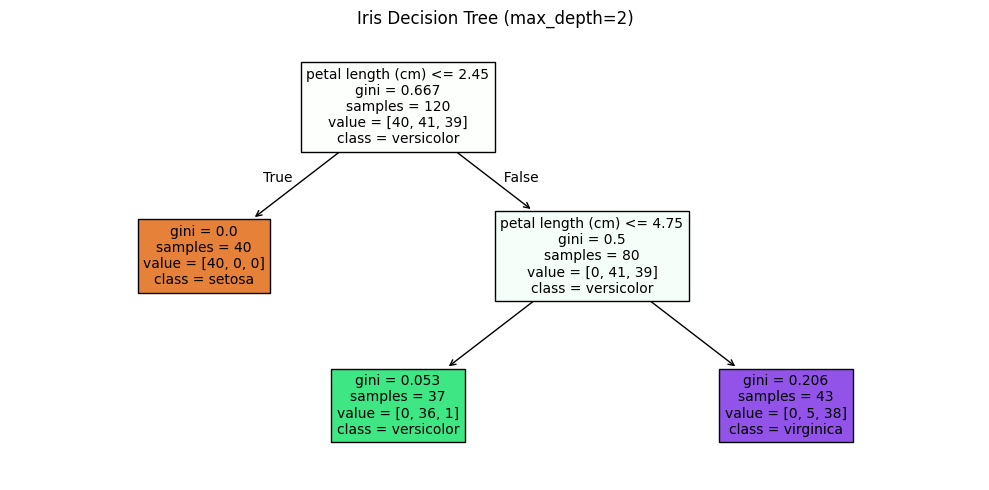

In [ ]:
plt.figure(figsize=(10, 5))
plot_tree(tree, feature_names=iris.feature_names,
class_names=iris.target_names,
filled=True, rounded=False, fontsize=10)
plt.title('Iris Decision Tree (max_depth=2)'); plt.tight_layout(); plt.show()

In [ ]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]
pred = tree.predict(new_flower)[0]
print(f'Predicted species: {iris.target_names[pred]}')
print(f'Probabilities : {tree.predict_proba(new_flower)[0]}')

Predicted species: setosa
Probabilities : [1. 0. 0.]


Calculate Gini manually first, then let sklearn demonstrate the same logic:


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
def gini_impurity(labels):
    """Calculate Gini impurity for a list of class labels."""
    labels = np.array(labels)
    n = len(labels)
    if n == 0: return 0
    classes = np.unique(labels)
    gini = 1.0
    for c in classes:
        p = np.sum(labels == c) / n
        gini -= p ** 2
    return gini

In [ ]:
print('Pure node (all same) :', gini_impurity([1,1,1,1,1]))
print('50-50 split :', gini_impurity([0,0,0,1,1,1]))
print('70-30 split :', gini_impurity([0,0,0,0,0,0,0,1,1,1]))
print('90-10 split :', gini_impurity([0]*9 + [1]))

Pure node (all same) : 0.0
50-50 split : 0.5
70-30 split : 0.42000000000000004
90-10 split : 0.17999999999999994


In [ ]:
def weighted_gini(left_labels, right_labels):
    """Gini after a split — weighted by group size."""
    n_total = len(left_labels) + len(right_labels)
    w_left = len(left_labels) / n_total
    w_right = len(right_labels) / n_total
    return w_left * gini_impurity(left_labels) + w_right * gini_impurity(right_labels)

In [ ]:
left_A = [0,0,0,0,1]
right_A = [0,1,1,1,1]

In [ ]:
left_B = [0,0,1,1,0]
right_B = [0,1,0,1,1]

In [ ]:
print(f'Weighted Gini — Glucose split: {weighted_gini(left_A, right_A):.3f}')
print(f'Weighted Gini — Age split : {weighted_gini(left_B, right_B):.3f}')
print('Tree picks the split with LOWER weighted Gini → Glucose split is better!')

Weighted Gini — Glucose split: 0.320
Weighted Gini — Age split : 0.480
Tree picks the split with LOWER weighted Gini → Glucose split is better!


In [ ]:
from sklearn.datasets import make_classification
from sklearn.tree import export_text
X, y = make_classification(n_samples=200, n_features=4, random_state=42)
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X, y)
print(export_text(tree, feature_names=['F1','F2','F3','F4']))

|--- F1 <= -0.15
|   |--- F3 <= -0.44
|   |   |--- class: 0
|   |--- F3 >  -0.44
|   |   |--- class: 0
|--- F1 >  -0.15
|   |--- F3 <= 0.63
|   |   |--- class: 1
|   |--- F3 >  0.63
|   |   |--- class: 0



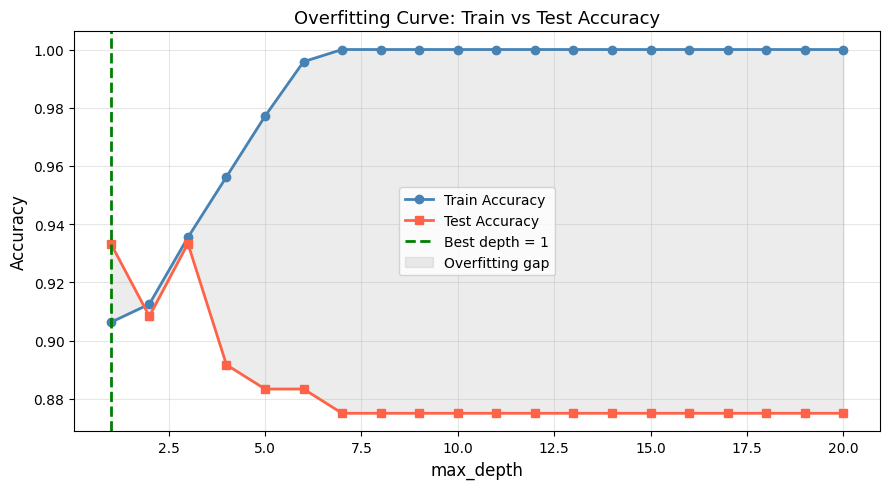

Best test accuracy 93.33% at depth=1


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
X, y = make_classification(n_samples=600, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
depths = range(1, 21)
train_acc, test_acc = [], []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc.append(accuracy_score(y_test, tree.predict(X_test)))
best_depth = depths[test_acc.index(max(test_acc))]
plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, 'o-', color='steelblue', lw=2, label='Train Accuracy')
plt.plot(depths, test_acc, 's-', color='tomato', lw=2, label='Test Accuracy')
plt.axvline(x=best_depth, color='green', linestyle='--', lw=2,
            label=f'Best depth = {best_depth}')
plt.fill_between(depths,
                 train_acc, test_acc,
                 alpha=0.15, color='gray', label='Overfitting gap')
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Overfitting Curve: Train vs Test Accuracy', fontsize=13)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'Best test accuracy {max(test_acc):.2%} at depth={best_depth}')

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
configs = [
{'max_depth': None},
{'max_depth': 5},
{'max_depth': 5, 'min_samples_split': 10},
{'max_depth': 5, 'min_samples_leaf': 5},
{'max_depth': 5, 'max_features': 'sqrt'},
]
print(f'{'Config':45s} {'CV Score (mean±std)':20s}')
print('-' * 68)
for cfg in configs:
  tree = DecisionTreeClassifier(**cfg, random_state=42)
  scores = cross_val_score(tree, X, y, cv=5, scoring='accuracy')
  print(f'{str(cfg):45s} {scores.mean():.3f} ± {scores.std():.3f}')

Config                                        CV Score (mean±std) 
--------------------------------------------------------------------
{'max_depth': None}                           0.885 ± 0.031
{'max_depth': 5}                              0.885 ± 0.023
{'max_depth': 5, 'min_samples_split': 10}     0.887 ± 0.029
{'max_depth': 5, 'min_samples_leaf': 5}       0.900 ± 0.030
{'max_depth': 5, 'max_features': 'sqrt'}      0.870 ± 0.026


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np, matplotlib.pyplot as plt, time
X, y = make_classification(n_samples=1000, n_features=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
rf_oob = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)
print(f'OOB Score : {rf_oob.oob_score_:.2%} ← estimated on ~37% unseen rows per tree')
print(f'Test Score : {rf_oob.score(X_test, y_test):.2%} ← actual held-out test')
print('OOB score is a free estimate — no need for a separate validation set!')

OOB Score : 88.88% ← estimated on ~37% unseen rows per tree
Test Score : 92.50% ← actual held-out test
OOB score is a free estimate — no need for a separate validation set!


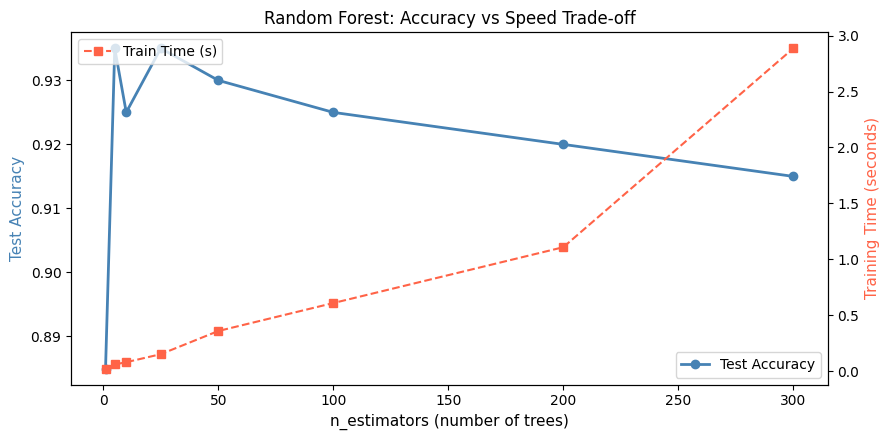

In [ ]:
n_trees_list = [1, 5, 10, 25, 50, 100, 200, 300]
accs, times = [], []
for n in n_trees_list:
  t0 = time.time()
  rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
  rf.fit(X_train, y_train)
  accs.append(accuracy_score(y_test, rf.predict(X_test)))
  times.append(time.time() - t0)
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax2 = ax1.twinx()
ax1.plot(n_trees_list, accs, 'o-', color='steelblue', lw=2, label='Test Accuracy')
ax2.plot(n_trees_list, times, 's--', color='tomato', lw=1.5, label='Train Time (s)')
ax1.set_xlabel('n_estimators (number of trees)', fontsize=11)
ax1.set_ylabel('Test Accuracy', color='steelblue', fontsize=11)
ax2.set_ylabel('Training Time (seconds)', color='tomato', fontsize=11)
ax1.set_title('Random Forest: Accuracy vs Speed Trade-off')
ax1.legend(loc='lower right'); ax2.legend(loc='upper left')
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
import pandas as pd, numpy as np, matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import os
if not os.path.exists('diabetes.csv'):
    !wget https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
df = pd.read_csv('diabetes.csv')
fix_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in fix_cols: df[col] = df[col].replace(0, df[col].median())
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

--2026-06-02 05:53:52--  https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23873 (23K) [text/plain]
Saving to: ‘diabetes.csv’

diabetes.csv        100%[===================>]  23.31K  --.-KB/s    in 0s      

2026-06-02 05:53:52 (88.0 MB/s) - ‘diabetes.csv’ saved [23873/23873]



RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Feature Importances (higher = more important):')
print(imp.round(3))

Feature Importances (higher = more important):
Glucose                     0.259
BMI                         0.163
Age                         0.147
DiabetesPedigreeFunction    0.117
BloodPressure               0.088
Pregnancies                 0.078
Insulin                     0.076
SkinThickness               0.071
dtype: float64


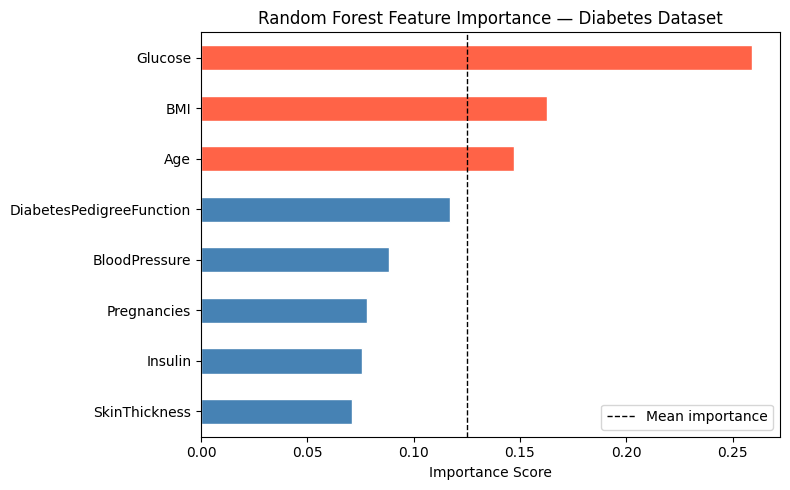

In [ ]:
imp_sorted = imp.sort_values()
colors = ['tomato' if v > imp.mean() else 'steelblue' for v in imp_sorted]
imp_sorted.plot(kind='barh', color=colors, figsize=(8,5), edgecolor='white')
plt.axvline(x=imp.mean(), color='black', linestyle='--', linewidth=1, label='Mean importance')
plt.title('Random Forest Feature Importance — Diabetes Dataset', fontsize=12)
plt.xlabel('Importance Score'); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
top_features = imp[imp > imp.mean()].index.tolist()
print(f'\nTop features (above average): {top_features}')
rf_top = RandomForestClassifier(n_estimators=200, random_state=42)
rf_top.fit(X_train[top_features], y_train)
full_acc = rf.score(X_test, y_test)
top_acc = rf_top.score(X_test[top_features], y_test)
print(f'Accuracy with all {len(X.columns)} features : {full_acc:.2%}')
print(f'Accuracy with top {len(top_features)} features : {top_acc:.2%}')
print('Often comparable — low-importance features can add noise!')


Top features (above average): ['Glucose', 'BMI', 'Age']
Accuracy with all 8 features : 77.27%
Accuracy with top 3 features : 72.73%
Often comparable — low-importance features can add noise!


LAB

In [ ]:
#1
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import os
if not os.path.exists('mushrooms.csv'):
    !wget https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data -O mushrooms.csv
df = pd.read_csv('mushrooms.csv')
column_names = ['class'] + [f'feature_{i}' for i in range(22)]
df = pd.read_csv('mushrooms.csv', header=None, names=column_names)
print(df.shape)
print(df['class'].value_counts())
le = LabelEncoder()
df_enc = df.copy()
for col in df_enc.columns:
    df_enc[col] = le.fit_transform(df_enc[col])
X = df_enc.drop('class', axis=1)
y = df_enc['class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)} rows | Test: {len(X_test)} rows')

--2026-06-02 08:09:15--  https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘mushrooms.csv’

mushrooms.csv           [  <=>               ] 364.95K  1.42MB/s    in 0.3s    

2026-06-02 08:09:16 (1.42 MB/s) - ‘mushrooms.csv’ saved [373704]

(8124, 23)
class
e    4208
p    3916
Name: count, dtype: int64
Train: 6499 rows | Test: 1625 rows


Decision Tree (depth=4) accuracy: 98.22%
|--- feature_8 <= 3.50
|   |--- feature_20 <= 3.50
|   |   |--- feature_19 <= 1.50
|   |   |   |--- class: 1
|   |   |--- feature_19 >  1.50
|   |   |   |--- feature_21 <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- feature_21 >  0.50
|   |   |   |   |--- class: 0
|   |--- feature_20 >  3.50
|   |   |--- feature_10 <= 2.00
|   |   |   |--- feature_12 <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- feature_12 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- feature_10 >  2.00
|   |   |   |--- class: 0
|--- feature_8 >  3.50
|   |--- feature_19 <= 1.50
|   |   |--- feature_10 <= 0.50
|   |   |   |--- class: 0
|   |   |--- feature_10 >  0.50
|   |   |   |--- class: 1
|   |--- feature_19 >  1.50
|   |   |--- feature_7 <= 0.50
|   |   |   |--- feature_17 <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- feature_17 >  0.50
|   |   |   |   |--- class: 0
|   |   |--- feature_7 >  0.50
|   |   |   |--- feature_9 <= 0.50
|   |   |   

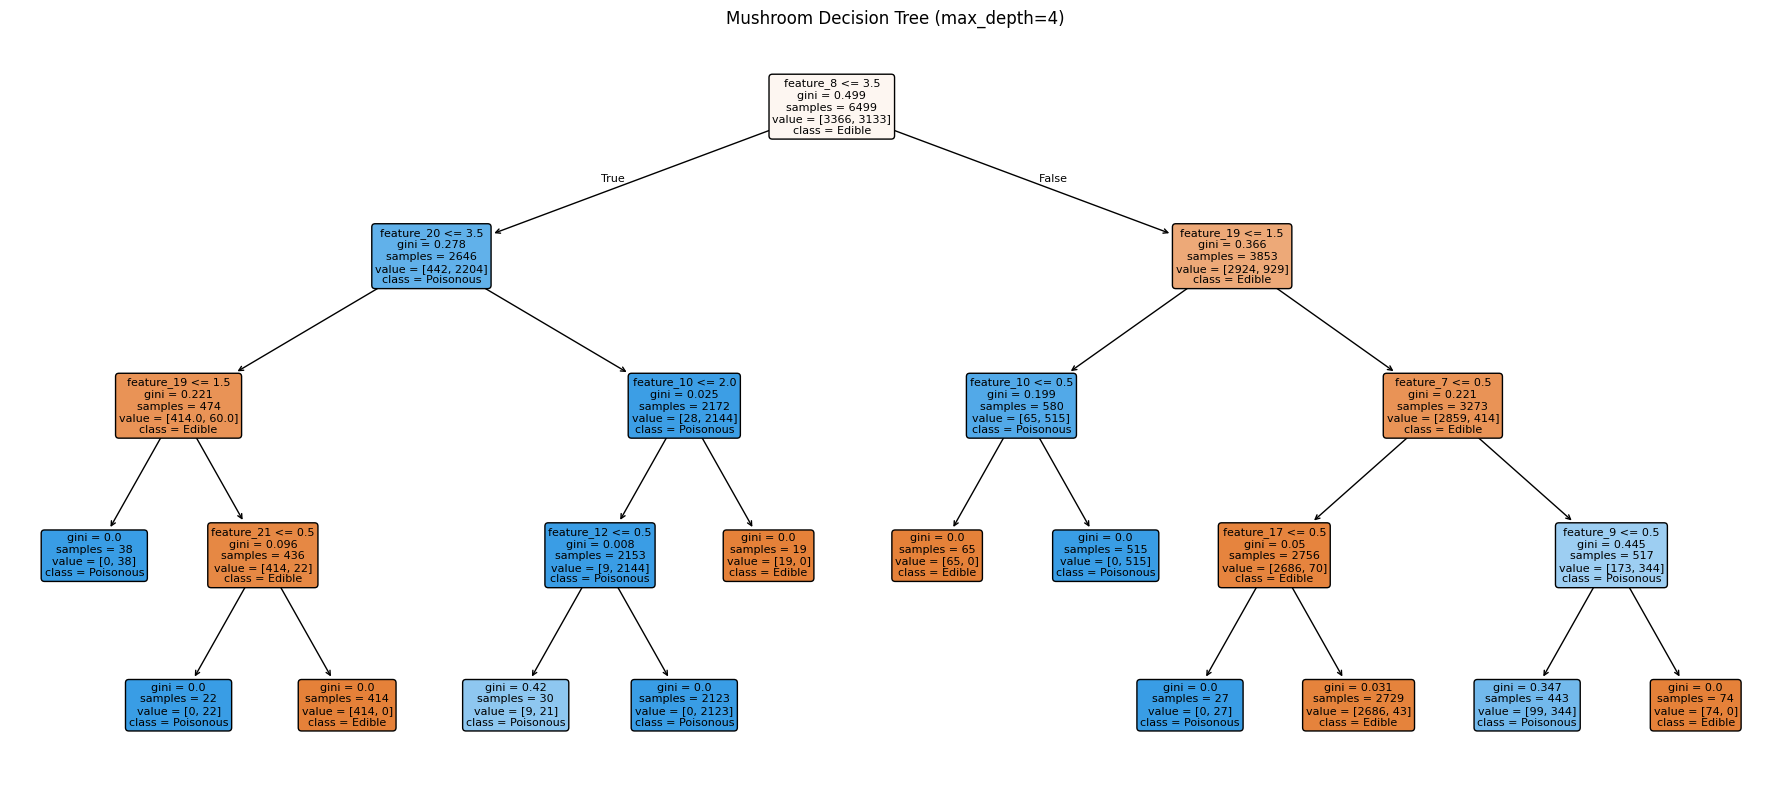

In [ ]:
#2
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
print(f'Decision Tree (depth=4) accuracy: {dt.score(X_test, y_test):.2%}')
print(export_text(dt, feature_names=list(X.columns)))
imp = pd.Series(dt.feature_importances_, index=X.columns)
top = imp.idxmax()
print(f'Most important feature: {top} (importance={imp[top]:.3f})')
plt.figure(figsize=(18, 8))
plot_tree(dt, feature_names=X.columns, class_names=['Edible','Poisonous'],
filled=True, rounded=True, fontsize=8)
plt.title('Mushroom Decision Tree (max_depth=4)'); plt.tight_layout()
plt.savefig('mushroom_tree.png', dpi=150, bbox_inches='tight')
plt.show()

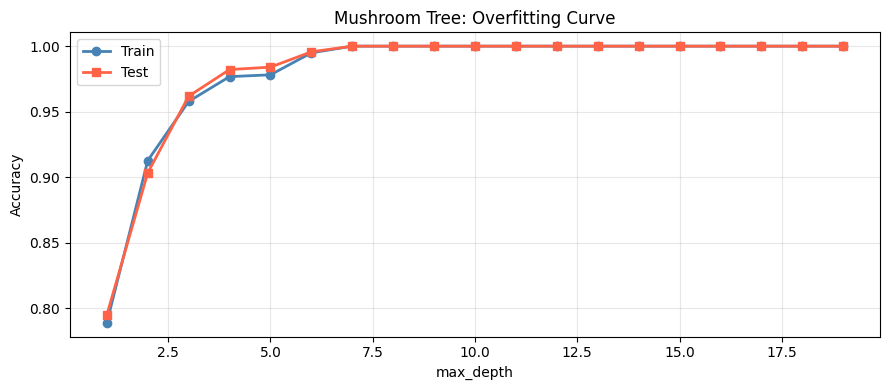

Best depth: 7, Test accuracy: 100.00%


In [ ]:
#3
train_acc, test_acc = [], []
for d in range(1, 20):
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc.append(tree.score(X_train, y_train))
    test_acc.append(tree.score(X_test, y_test))
plt.figure(figsize=(9, 4))
plt.plot(range(1,20), train_acc, 'o-', lw=2, label='Train', color='steelblue')
plt.plot(range(1,20), test_acc, 's-', lw=2, label='Test', color='tomato')
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Mushroom Tree: Overfitting Curve')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
best = range(1,20)[test_acc.index(max(test_acc))]
print(f'Best depth: {best}, Test accuracy: {max(test_acc):.2%}')

Random Forest Test Accuracy: 100.00%
Random Forest OOB Accuracy: 100.00%
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

5-Fold CV: 88.54% ± 16.24%


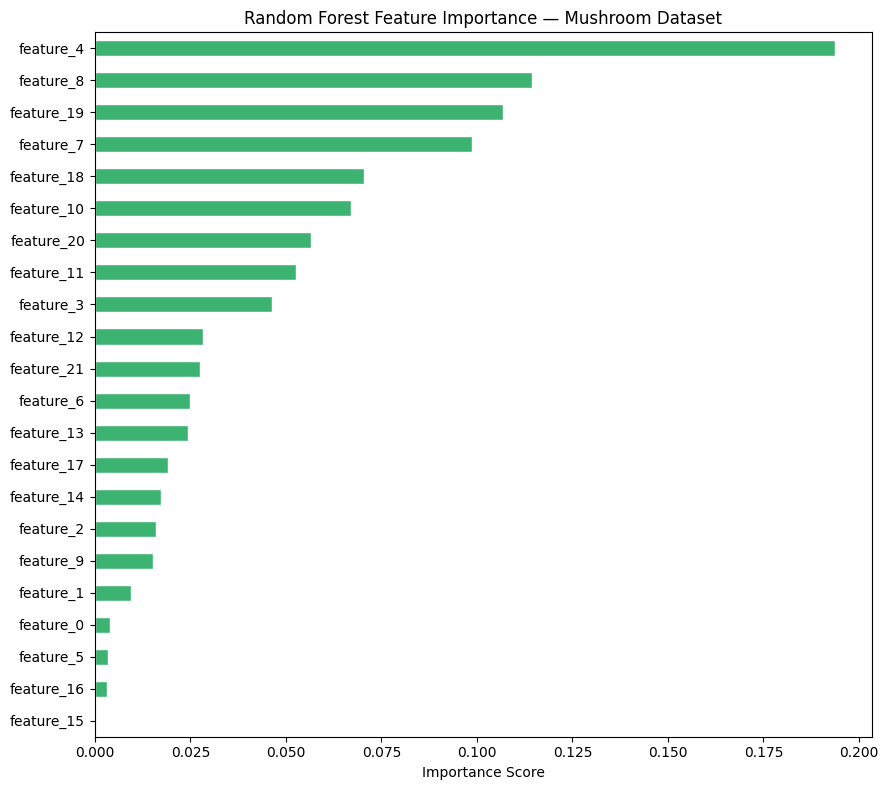


Accuracy WITHOUT odor feature: 100.00%
Accuracy WITH odor feature: 100.00%


In [ ]:
#4
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f'Random Forest Test Accuracy: {rf.score(X_test, y_test):.2%}')
print(f'Random Forest OOB Accuracy: {rf.oob_score_:.2%}')
print(classification_report(y_test, rf.predict(X_test), target_names=['Edible','Poisonous']))
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f'5-Fold CV: {cv_scores.mean():.2%} ± {cv_scores.std():.2%}')
rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
rf_imp.plot(kind='barh', figsize=(9, 8), color='mediumseagreen', edgecolor='white')
plt.title('Random Forest Feature Importance — Mushroom Dataset', fontsize=12)
plt.xlabel('Importance Score'); plt.tight_layout(); plt.show()
X_no_odor = X.drop(columns=['feature_8'])
X_tr2, X_te2, ytr, yte = train_test_split(X_no_odor, y, test_size=0.2, random_state=42)
rf2 = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr2, ytr)
print(f'\nAccuracy WITHOUT odor feature: {rf2.score(X_te2, yte):.2%}')
print(f'Accuracy WITH odor feature: {rf.sc       ore(X_test, y_test):.2%}')

In [ ]:
sample_index = 0
sample = X_test.iloc[[sample_index]]
true_label = y_test.iloc[sample_index]
pred = rf.predict(sample)[0]
prob = rf.predict_proba(sample)[0]
label = 'Edible' if pred == 0 else 'POISONOUS'
actual = 'Edible' if true_label == 0 else 'POISONOUS'
print(f'Prediction : {label}')
print(f'Actual : {actual}')
print(f'Confidence : {max(prob):.1%}')
print(f'Correct? : {'Yes!' if pred == true_label else 'No...'}')
for i in range(10):
    samp = X_test.iloc[[i]]
    pred = rf.predict(samp)[0]
    conf = max(rf.predict_proba(samp)[0])
    true = y_test.iloc[i]
    mark = '✓' if pred == true else '✗'
    predicted_label_str = 'Edible' if pred == 0 else 'Poisonous'
    actual_label_str = 'Edible' if true == 0 else 'Poisonous'
    print(f'{mark} Pred: {predicted_label_str:9s} | Conf: {conf:.0%} | Actual: {actual_label_str}')

Prediction : POISONOUS
Actual : POISONOUS
Confidence : 100.0%
Correct? : Yes!
✓ Pred: Poisonous | Conf: 100% | Actual: Poisonous
✓ Pred: Poisonous | Conf: 100% | Actual: Poisonous
✓ Pred: Edible    | Conf: 100% | Actual: Edible
✓ Pred: Poisonous | Conf: 100% | Actual: Poisonous
✓ Pred: Poisonous | Conf: 100% | Actual: Poisonous
✓ Pred: Edible    | Conf: 100% | Actual: Edible
✓ Pred: Edible    | Conf: 100% | Actual: Edible
✓ Pred: Edible    | Conf: 100% | Actual: Edible
✓ Pred: Edible    | Conf: 100% | Actual: Edible
✓ Pred: Poisonous | Conf: 100% | Actual: Poisonous
